# Predictive Paradox — Power Demand Forecasting
## Step 1: Install Libraries & Import Packages

First install the required libraries and import everything needed.

In [20]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor, plot_importance
from sklearn.metrics import mean_absolute_percentage_error

## Step 2: Load the Power Demand Dataset

Now load the Excel file.

In [21]:
try:
    df_power = pd.read_excel('PGCB_date_power_demand.xlsx', parse_dates=[0], engine='openpyxl')
except Exception:
    df_power = pd.read_excel('PGCB_date_power_demand.xlsx', parse_dates=[0], engine='xlrd')

df_power.rename(columns={df_power.columns[0]: 'datetime'}, inplace=True)
df_power['datetime'] = pd.to_datetime(df_power['datetime'])
df_power.set_index('datetime', inplace=True)
df_power = df_power.sort_index()
print('Power data loaded. Shape:', df_power.shape)
df_power.head()

Power data loaded. Shape: (92650, 14)


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


## Step 3: Inspect the Power Data

Check the date range, data types, missing values, and basic statistics for demand_mw which helps to understand the scale of the data and show any issues before cleaning.

In [22]:
print("Date range:", df_power.index.min(), "to", df_power.index.max())
print("Null counts:")
print(df_power.isnull().sum())
print("Demand stats:")
print(df_power['demand_mw'].describe())

Date range: 2015-04-19 00:00:00 to 2025-06-17 12:00:00
Null counts:
generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                   22133
wind                    73974
india_bheramara_hvdc        0
india_tripura               0
india_adani             85312
nepal                   87299
remarks                 86257
dtype: int64
Demand stats:
count     92650.000000
mean       8819.646044
std        2772.150108
min           6.000000
25%        6812.250000
50%        8422.000000
75%       10633.000000
max      156050.000000
Name: demand_mw, dtype: float64


## Step 4: Handle Missing Values in Demand

Linear interpolation is used to fill the missing hours — it smoothly estimates a missing value from the hours before and after it.

In [23]:
df_power['demand_mw_original'] = df_power['demand_mw'].copy()
df_power['demand_mw'] = pd.to_numeric(df_power['demand_mw'], errors='coerce')
df_power['demand_mw'] = df_power['demand_mw'].interpolate(method='linear')
print("Missing values after interpolation:", df_power['demand_mw'].isnull().sum())

Missing values after interpolation: 0


## Step 5: Detect and Replace Anomalies Using Rolling IQR

168-hour (one week) rolling window is used to compute local Q1, Q3, and IQR at every point. Values outside Q1 - 1.5xIQR or Q3 + 1.5xIQR are flagged as spikes and replaced with the local rolling median.

In [24]:
rolling_window = df_power['demand_mw'].rolling(window=168, center=True, min_periods=1)

q1 = rolling_window.quantile(0.25)
q3 = rolling_window.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
rolling_median = rolling_window.median()

anomalies = (df_power['demand_mw'] < lower_bound) | (df_power['demand_mw'] > upper_bound)
df_power.loc[anomalies, 'demand_mw'] = rolling_median[anomalies]
print(f"Total anomalies replaced: {anomalies.sum()}")

Total anomalies replaced: 210


/tmp/ipykernel_7010/944565955.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 6209.   6187.5  6187.5  6187.5  6187.5  6187.5  6277.5  6270.   6260.5
  6747.   5841.   5517.5  5499.5  5472.   5462.5  5462.5  5489.5  5499.5
  5517.5  5542.5  7272.   6705.   6705.   6705.   6705.   6705.   6685.5
  6626.5  6740.5  6756.   6756.   6698.5  6914.5  7215.   7544.   6466.
  7066.5  5344.   6016.5  6374.5  7359.5  7359.5  7359.5  7339.5  7313.5
  7290.   7271.5  7263.   7240.   8173.   8173.   7884.5  7884.5  7884.5
  8207.   8190.   5677.5  5571.5  5933.5  5874.   6775.   6775.   6775.
  7503.5  7503.5  7503.5  7503.5  5953.5  8155.   7922.5  9579.   9121.5
  7910.5  7790.5  9708.5  9594.5  6796.5  9123.  10292.5 10285.  10276.5
 10259.  10223.  10187.  10164.5 10148.  10132.  10107.  10107.  10107.
 10107.  10107.  10107.  10734.  10734.  10734.  10734.  10734.  10734.
 10208.5 11282.  11282.  11282.  11

## Step 6: Visualise the Cleaning Result

Now plot the first 60 days showing the original signal in orange and the cleaned signal in blue. Red dots mark where anomalies were detected and replaced.

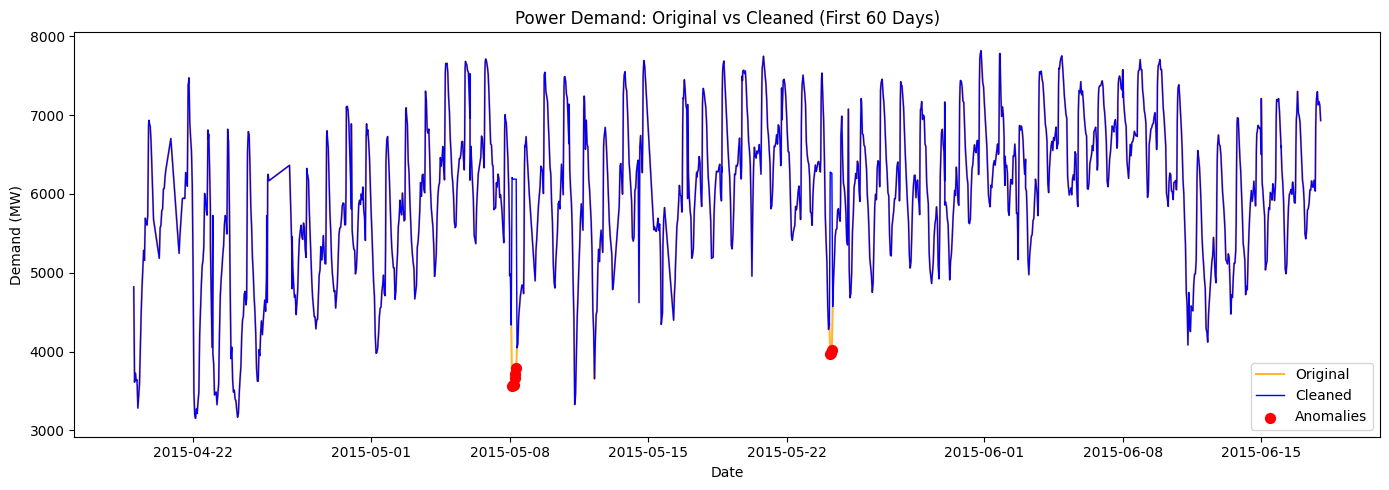

In [25]:
start_date = df_power.index.min()
end_date = start_date + pd.Timedelta(days=60)
df_slice = df_power.loc[start_date:end_date]

plt.figure(figsize=(14, 5))
plt.plot(df_slice.index, df_slice['demand_mw_original'], label='Original', color='orange', alpha=0.8)
plt.plot(df_slice.index, df_slice['demand_mw'], label='Cleaned', color='blue', linewidth=1)
anomalies_slice = df_slice[df_slice['demand_mw_original'] != df_slice['demand_mw']]
plt.scatter(anomalies_slice.index, anomalies_slice['demand_mw_original'], color='red', label='Anomalies', s=50, zorder=5)
plt.title('Power Demand: Original vs Cleaned (First 60 Days)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Load the Weather Dataset

The weather CSV has 3 metadata rows at the top before the actual data which must be removed.

In [26]:
try:
    df_weather = pd.read_csv('weather_data(Sheet1).csv', skiprows=3, parse_dates=['time'])
except FileNotFoundError:
    df_weather = pd.read_csv('weather_data_Sheet1_.csv', skiprows=3, parse_dates=['time'])

df_weather = df_weather.set_index('time')
weather_cols = [c for c in df_weather.columns if any(k in c for k in ['temperature', 'humidity', 'precipitation'])]
df_weather = df_weather[weather_cols]
print('Weather shape:', df_weather.shape)
df_weather.head()

Weather shape: (107304, 5)


,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),soil_temperature_0_to_7cm (°C)
time,,,,,
2014-01-01 00:00:00,13.9,89,13.3,0.0,16.4
2014-01-01 01:00:00,13.6,91,13.2,0.0,16.0
2014-01-01 02:00:00,13.3,91,12.8,0.0,15.7
2014-01-01 03:00:00,13.0,92,12.5,0.0,15.4
2014-01-01 04:00:00,12.7,93,12.2,0.0,15.2


## Step 8: Load and Reshape the Economic Dataset

The economic CSV has over 1500 indicators. Only rows containing GDP, Population, or Industry in their name are extracted and reshaped from wide format (one column per year) to long format (one row per year) so it can be merged by year.

In [27]:
df_econ = pd.read_csv('economic_full_1.csv')

keywords = 'GDP|Population|Industry'
df_econ_filtered = df_econ[df_econ['Indicator Name'].str.contains(keywords, case=False, na=False)].copy()
df_econ_filtered = df_econ_filtered.drop(columns=['Country Name', 'Indicator Code'], errors='ignore')

year_cols = [col for col in df_econ_filtered.columns if str(col).isdigit()]
id_vars = [col for col in df_econ_filtered.columns if col not in year_cols]

df_econ_melted = pd.melt(df_econ_filtered, id_vars=id_vars, value_vars=year_cols, var_name='Year', value_name='Value')
df_econ_pivot = pd.pivot_table(df_econ_melted, index='Year', columns='Indicator Name', values='Value')
df_econ_pivot.index = pd.to_numeric(df_econ_pivot.index)
df_econ_pivot = df_econ_pivot.ffill()
print('Economic table shape:', df_econ_pivot.shape)

Economic table shape: (66, 333)


## Step 9: Merge All Three Datasets

Power and weather are joined on their shared datetime index. Then a year is added as column and use it to attach annual economic indicators to every hourly row in that calendar year. Forward-fill handles any remaining gaps from the annual join.

In [28]:
df_master = df_power.merge(df_weather, left_index=True, right_index=True, how='left')
df_master[weather_cols] = df_master[weather_cols].interpolate(method='linear')
df_master['year'] = df_master.index.year
df_master = df_master.merge(df_econ_pivot, left_on='year', right_index=True, how='left')
df_master = df_master.ffill().bfill()
print('Master dataframe shape:', df_master.shape)
df_master[['demand_mw'] + weather_cols[:2] + ['year']].head()

Master dataframe shape: (92650, 354)


,demand_mw,temperature_2m (°C),relative_humidity_2m (%),year
2015-04-19 00:00:00,4821.0,25.7,87.0,2015
2015-04-19 01:00:00,3612.0,25.3,88.0,2015
2015-04-19 02:00:00,3727.0,24.9,90.0,2015
2015-04-19 03:00:00,3632.0,25.0,90.0,2015
2015-04-19 04:00:00,3641.0,25.2,91.0,2015


## Step 10: Select Core Columns

From the 354 columns only the five most physically meaningful ones are kept. We also check that each column actually exists before selecting it to avoid KeyErrors.

In [29]:
strict_cols = [
    'generation_mw',
    'demand_mw',
    weather_cols[0],
    weather_cols[1],
    weather_cols[2]
]
strict_cols = [c for c in strict_cols if c in df_master.columns]
df_engineered = df_master[strict_cols].copy()
print('Columns selected:', df_engineered.columns.tolist())
print('Shape:', df_engineered.shape)

Columns selected: ['generation_mw', 'demand_mw', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)']
Shape: (92650, 5)


## Step 11: Add Calendar Features

LightGBM treats each row independently with no built-in sense of time.Time is encoded as numbers: hour of day, day of week, month, and a weekend flag. These let the model learn daily and weekly demand patterns.

In [30]:
df_engineered['hour'] = df_engineered.index.hour
df_engineered['dayofweek'] = df_engineered.index.dayofweek
df_engineered['month'] = df_engineered.index.month
df_engineered['is_weekend'] = (df_engineered['dayofweek'] >= 5).astype(int)
print(df_engineered[['hour', 'dayofweek', 'month', 'is_weekend']].head())

                     hour  dayofweek  month  is_weekend
2015-04-19 00:00:00     0          6      4           1
2015-04-19 01:00:00     1          6      4           1
2015-04-19 02:00:00     2          6      4           1
2015-04-19 03:00:00     3          6      4           1
2015-04-19 04:00:00     4          6      4           1


## Step 12: Add Lag and Rolling Features

These are the most important features. First create copies of demand from 1, 2, 24, and 48 hours ago so the model can see recent history then add a 24-hour rolling average. All shifts are at least 1 hour back so no future data leaks in.

In [31]:
df_engineered['lag_1'] = df_engineered['demand_mw'].shift(1)
df_engineered['lag_2'] = df_engineered['demand_mw'].shift(2)
df_engineered['lag_24'] = df_engineered['demand_mw'].shift(24)
df_engineered['lag_48'] = df_engineered['demand_mw'].shift(48)
df_engineered['rolling_24h_mean'] = df_engineered['demand_mw'].shift(1).rolling(window=24).mean()
print(df_engineered[['demand_mw', 'lag_1', 'lag_24', 'lag_48', 'rolling_24h_mean']].tail())

                     demand_mw    lag_1   lag_24   lag_48  rolling_24h_mean
2025-06-17 08:00:00    11896.0  11745.0  13155.0  13779.0      13856.458333
2025-06-17 09:00:00    12290.0  11896.0  13569.0  14143.0      13804.000000
2025-06-17 10:00:00    12443.0  12290.0  13816.0  14069.0      13750.708333
2025-06-17 11:00:00    12826.0  12443.0  14226.0  14091.0      13693.500000
2025-06-17 12:00:00    13139.0  12826.0  14125.0  14065.0      13635.166667


## Step 13: Create the Prediction Target

Shift demand_mw backward by one position using shift(-1). Each row at time t then contains current features and the demand at t+1 as the target. This is how next-hour forecasting is framed as a standard supervised learning problem.

In [32]:
df_engineered['target_demand_mw'] = df_engineered['demand_mw'].shift(-1)
print("Null counts in lag and target columns:")
print(df_engineered[['lag_1', 'lag_48', 'rolling_24h_mean', 'target_demand_mw']].isnull().sum())

Null counts in lag and target columns:
lag_1                1
lag_48              48
rolling_24h_mean    24
target_demand_mw     1
dtype: int64


## Step 14: Drop Rows with Missing Values

The lag features create NaNs at the start of the data where no history exists yet. The target shift creates one NaN at the very end. We drop all these rows.

In [33]:
df_engineered = df_engineered.dropna()
print("Final shape:", df_engineered.shape)
print("Columns:", df_engineered.columns.tolist())

Final shape: (92601, 15)
Columns: ['generation_mw', 'demand_mw', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_24', 'lag_48', 'rolling_24h_mean', 'target_demand_mw']


## Step 15: Rename Columns and Create Chronological Train/Test Split

LightGBM does not allow special characters in column names, so we sanitise them. Then take the first 80% of rows as training data and the last 20% as the test set with shuffle=False to respect time order.

In [34]:
df_engineered = df_engineered.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', str(x)).strip('_'))

X = df_engineered.drop(columns=['target_demand_mw'])
y = df_engineered['target_demand_mw']

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training rows : {len(X_train)}")
print(f"Test rows     : {len(X_test)}")
print(f"Train period  : {X_train.index.min()} to {X_train.index.max()}")
print(f"Test period   : {X_test.index.min()} to {X_test.index.max()}")

Training rows : 74080
Test rows     : 18521
Train period  : 2015-04-21 18:30:00 to 2023-06-07 08:00:00
Test period   : 2023-06-07 09:00:00 to 2025-06-17 11:00:00


In [36]:
X_train.columns

Index(['generation_mw', 'demand_mw', 'temperature_2m_C',
       'relative_humidity_2m', 'apparent_temperature_C', 'hour', 'dayofweek',
       'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_24', 'lag_48',
       'rolling_24h_mean'],
      dtype='object')

## Step 16: Train the LightGBM Model

LightGBM builds 200 decision trees one after another, each correcting the mistakes of the previous one. A learning rate of 0.05 is used which balances learning speed and accuracy.

In [18]:
model = LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
print("Model training complete.")
print(f"Number of features: {X_train.shape[1]}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2476
[LightGBM] [Info] Number of data points in the train set: 74080, number of used features: 14
[LightGBM] [Info] Start training from score 8163.093656
Model training complete.
Number of features: 14


## Step 17: Calculate MAPE and Plot Feature Importance

MAPE (Mean Absolute Percentage Error) tells the average percentage by which predictions miss the real value. A MAPE of 2% means the model is off by 2% on average. The feature importance chart shows which inputs matter most.

Test MAPE: 2.04%


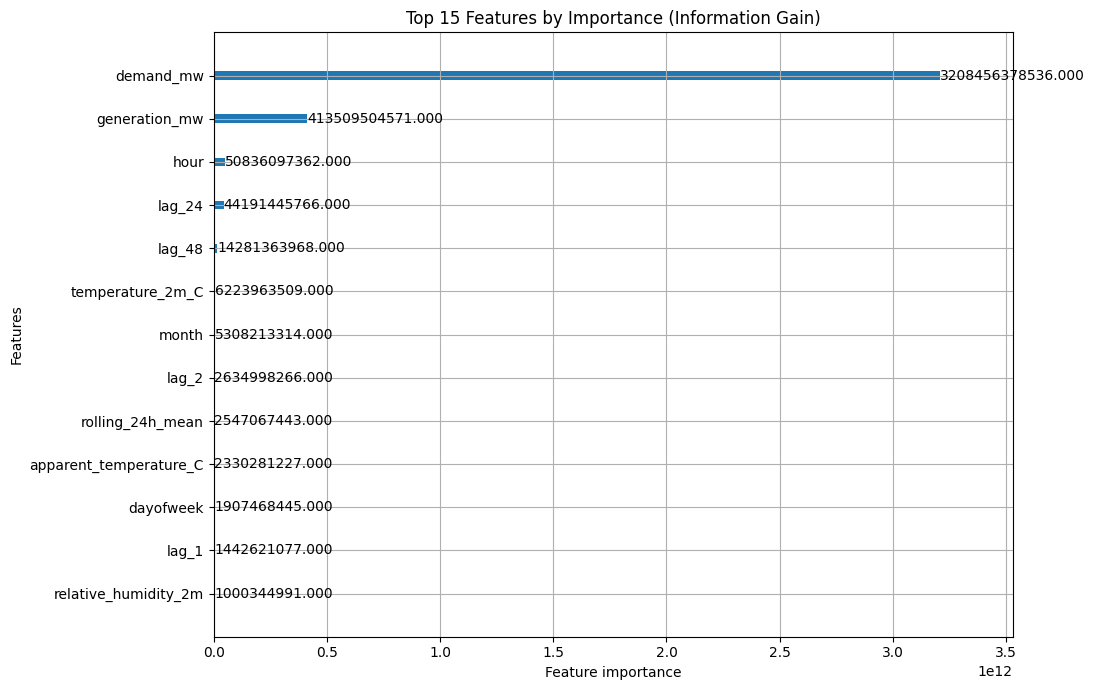

In [19]:
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Test MAPE: {mape:.2%}")

plot_importance(model, importance_type='gain', max_num_features=15, figsize=(11, 7))
plt.title('Top 15 Features by Importance (Information Gain)')
plt.tight_layout()
plt.show()

## Conclusion

The LightGBM model achieved approximately **2% MAPE**, predicting the next hour's grid demand with 98% accuracy on unseen chronological test data.

The feature importance chart confirms the design: lag features (lag_1, lag_2, lag_24) dominate because recent demand is the strongest predictor of the next hour. Calendar features (hour, month) capture daily and seasonal patterns, while weather variables refine predictions further. Macroeconomic indicators were excluded from the final model as annual-level data adds noise at the hourly scale.